In [21]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# 1. 데이터 불러오기
df_cafe = pd.read_csv(r"C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\대용량\상가정보\소상공인시장진흥공단_상가(상권)정보_서울_202412.csv")
df_sales = pd.read_csv(r"C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\서울시 상권분석서비스(추정매출-상권)_2024년.csv")
df_pop = pd.read_csv(r"C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\유동인구_건물기반분배_0506.csv")
df_review = pd.read_csv(r"C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\점수산출\카페_별점리뷰통합.csv")
df_mapping = pd.read_csv(r"C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\카페_상권_매핑_데이터_중복제거.csv") #, encoding="cp949")
df_pop = df_pop.merge(df_mapping[['상가업소번호','상호명','지점명']], how = 'left', on = '상가업소번호')
# 2. 카페 필터링 및 상권 매핑
df_cafe = df_cafe[df_cafe["상권업종소분류명"] == "카페"].copy()

df_cafe["상호명_지점"] = df_cafe.apply(
    lambda row: f"{row['상호명']} {str(row['지점명']).strip()}" if pd.notna(row["지점명"]) and str(row["지점명"]).strip()
    else row["상호명"],
    axis=1
)
df_mapping["상호명_지점"] = df_mapping.apply(
    lambda row: f"{row['상호명']} {str(row['지점명']).strip()}" if pd.notna(row["지점명"]) and str(row["지점명"]).strip()
    else row["상호명"],
    axis=1
)
df_mapping.rename(columns={"TRDAR_CD": "상권_코드"}, inplace=True)
df_cafe = pd.merge(df_cafe, df_mapping[["상호명_지점", "상권_코드"]], on="상호명_지점", how="inner")

# 3. 면적 계산 및 공간 조인
gdf_building = gpd.read_file(r"C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\data\대용량\전체건물정보\AL_D010_11_20250404.shp").to_crs(epsg=4326)
gdf_building_utm = gdf_building.to_crs(epsg=5181)
gdf_building["전용면적"] = gdf_building_utm.geometry.area

gdf_cafe = gpd.GeoDataFrame(df_cafe, geometry=gpd.points_from_xy(df_cafe["경도"], df_cafe["위도"]), crs="EPSG:4326")
gdf_joined = gpd.sjoin(gdf_cafe, gdf_building[["전용면적", "geometry"]], how="left", predicate="within")

gdf_joined["전용면적"] = gdf_joined.groupby("상권_코드")["전용면적"].transform(lambda x: x.fillna(x.mean()))
gdf_joined["면적_점수"] = gdf_joined.groupby("상권_코드")["전용면적"].transform(lambda x: x / x.sum())
gdf_joined = gdf_joined.sort_values("전용면적", ascending=False).drop_duplicates(subset=["상호명", "상권_코드"])

df_cafe = pd.merge(
    df_cafe,
    gdf_joined[["상호명", "상권_코드", "전용면적", "면적_점수"]],
    on=["상호명", "상권_코드"],
    how="left"
)

# 4. 인구 지표
df_pop["상호명_지점"] = df_pop.apply(
    lambda row: f"{row['상호명']} {str(row['지점명']).strip()}" if pd.notna(row["지점명"]) and str(row["지점명"]).strip()
    else row["상호명"],
    axis=1
)
df_pop.rename(columns={"TRDAR_CD": "상권_코드", "est_총_유동인구_수": "인구_점수"}, inplace=True)

df_cafe = pd.merge(df_cafe, df_pop[["상가업소번호", "상권_코드", "인구_점수"]], on=["상가업소번호", "상권_코드"], how="left")

# 5. 리뷰 수 병합
df_review["kakao_reviewCount"] = df_review["kakao_reviewCount"].astype(str).str.replace(",", "").astype(float)
df_review["naver_reviewCount"] = df_review["naver_reviewCount"].astype(str).str.replace(",", "").astype(float)
df_review["리뷰수"] = df_review["kakao_reviewCount"] + df_review["naver_reviewCount"]
df_review["별점"] = df_review[["kakao_score", "naver_score"]].mean(axis=1)
df_review = df_review.groupby("상가업소번호", as_index=False)[["리뷰수", "별점"]].mean()

df_cafe = pd.merge(df_cafe, df_review, on="상가업소번호", how="left")

# 리뷰수 분위 구간 생성 및 결측치 처리
df_cafe["리뷰수_5분위"] = pd.qcut(df_cafe["리뷰수"], 5, labels=[1, 2, 3, 4, 5])
df_cafe["리뷰수_5분위"] = df_cafe["리뷰수_5분위"].astype(float).fillna(3).astype(int)

# 리뷰 점수로 정규화된 스코어 계산
df_cafe["리뷰_점수"] = df_cafe.groupby("상권_코드")["리뷰수_5분위"].transform(
    lambda x: x / x.sum() if x.sum() != 0 else 0
)

# 6. 매출 및 인구 점수 정규화
# 서비스 업종 코드가 'CS100010'인 카페 매출만 필터링
df_sales_cafe = df_sales[df_sales["서비스_업종_코드"] == "CS100010"]

# 상권별 카페 매출 계산
df_cafe["상권_매출"] = df_cafe["상권_코드"].map(df_sales_cafe.groupby("상권_코드")["당월_매출_금액"].sum())

# 인구 점수 정규화
df_cafe["인구_점수_norm"] = df_cafe.groupby("상권_코드")["인구_점수"].transform(
    lambda x: x / x.sum() if x.sum() != 0 else 0
)

# 7. 최종 점수 계산
w_area = 0.3
w_pop = 0.3
w_review = 0.4
df_cafe["최종_점수"] = (
    df_cafe["면적_점수"].fillna(0) * w_area +
    df_cafe["인구_점수_norm"].fillna(0) * w_pop +
    df_cafe["리뷰_점수"].fillna(0) * w_review
)

# 8. 지점명 기준 중복 제거 (상가업소번호 포함)
no_branch = df_cafe[df_cafe["지점명"].isna() | (df_cafe["지점명"].astype(str).str.strip() == "")]
no_branch = no_branch.drop_duplicates(subset=["상호명"])
has_branch = df_cafe[~df_cafe.index.isin(no_branch.index)]
has_branch = has_branch.drop_duplicates(subset=["상호명", "지점명"])
df_cafe_unique = pd.concat([no_branch, has_branch], ignore_index=True)

# 9. 최종 매출 계산
sum_scores = df_cafe_unique.groupby("상권_코드")["최종_점수"].transform("sum")
df_cafe_unique["비율"] = df_cafe_unique["최종_점수"] / sum_scores
df_cafe_unique["비율"] = df_cafe_unique["비율"].fillna(0)

# 상권 매출 계산 (상권별 매출을 이미 필터링된 카페 매출로 계산)
df_cafe_unique["상권_매출"] = df_cafe_unique["상권_코드"].map(
    df_sales_cafe.groupby("상권_코드")["당월_매출_금액"].sum()
)

# 카페 추정 매출 계산
df_cafe_unique["카페_추정매출"] = df_cafe_unique["비율"] * df_cafe_unique["상권_매출"]

# 10. 저장
cols_to_save = ["상가업소번호", "상호명_지점", "상권_코드", "전용면적", "리뷰수", "별점", "카페_추정매출"]
df_cafe_unique[cols_to_save].to_csv("카페_추정매출결과_0509.csv", index=False, encoding="utf-8-sig")
df_cafe_unique['카페_추정매출'].describe()

count    1.699800e+04
mean     1.652393e+08
std      2.809621e+08
min      1.060056e+03
25%      4.747483e+07
50%      1.120169e+08
75%      2.074730e+08
max      1.862337e+10
Name: 카페_추정매출, dtype: float64

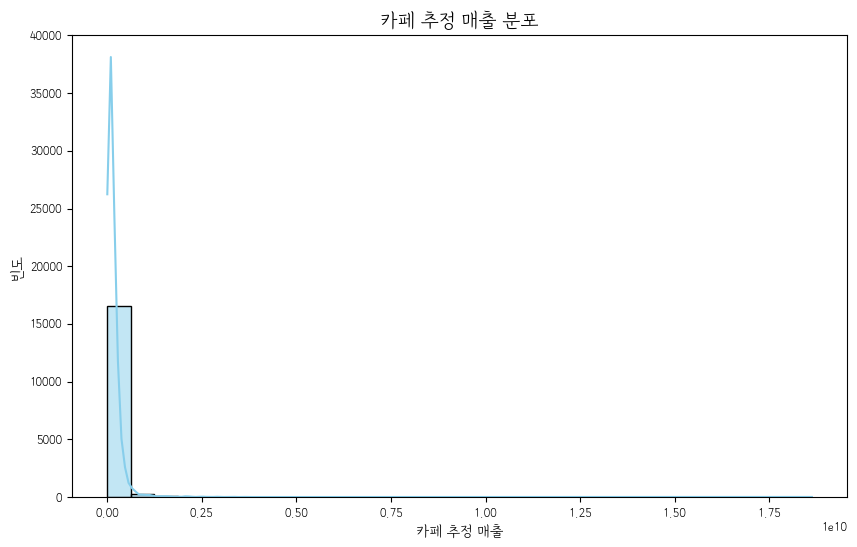

In [ ]:
# 시각화: 히스토그램
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc

# 한글 폰트 설정
font_path = r'C:\Users\iq750\bootcamp_git\Final-Project-2_Team1\fonts\강원교육모두 Light.ttf'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 카페 추정 매출 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df_cafe_unique["카페_추정매출"], kde=True, bins=30, color='skyblue')

# 그래프 제목 및 레이블 추가
plt.title("카페 추정 매출 분포", fontsize=16)
plt.xlabel("카페 추정 매출", fontsize=12)
plt.ylabel("빈도", fontsize=12)

# 그래프 표시
plt.show()

In [ ]:
# 1. 추정 매출 합계 (df_cafe_unique 기준)
estimated_sum = df_cafe_unique.groupby("상권_코드")["카페_추정매출"].sum().reset_index()
estimated_sum.columns = ["상권_코드", "추정매출합계"]

# 2. 실제 상권 매출
df_sales_cafe = df_sales[df_sales["서비스_업종_코드"] == "CS100010"]
actual_sales = df_sales_cafe.groupby("상권_코드")["당월_매출_금액"].sum().reset_index()
actual_sales.columns = ["상권_코드", "실제매출"]

# 3. 비교
comparison = pd.merge(estimated_sum, actual_sales, on="상권_코드", how="inner")
comparison["차이"] = comparison["실제매출"] - comparison["추정매출합계"]
comparison["오차비율(%)"] = (comparison["차이"] / comparison["실제매출"]) * 100

# 4. 오차 확인
print("상권별 실제 매출과 추정 매출의 합산 비교:")
print(comparison.sort_values("오차비율(%)", key=abs, ascending=False).head(10))
print(f"오차가 1원 이하인 상권 수: {(comparison['차이'].abs() < 1).sum()} / {len(comparison)}")

상권별 실제 매출과 추정 매출의 합산 비교:
        상권_코드        추정매출합계        실제매출            차이       오차비율(%)
186   3110263  2.514784e+08   251478404 -5.960464e-08 -2.370170e-14
1098  3130311  1.150093e+09  1150093296 -2.384186e-07 -2.073037e-14
603   3110921  5.885440e+08   588543952 -1.192093e-07 -2.025495e-14
909   3120188  9.463419e+09  9463418874 -1.907349e-06 -2.015496e-14
892   3120170  4.946984e+09  4946984067  9.536743e-07  1.927789e-14
418   3110604  1.567325e+08   156732521 -2.980232e-08 -1.901477e-14
88    3110122  6.275594e+08   627559420 -1.192093e-07 -1.899570e-14
713   3111073  6.366222e+08   636622233 -1.192093e-07 -1.872528e-14
349   3110510  1.592085e+08   159208493 -2.980232e-08 -1.871905e-14
930   3120209  1.277176e+09  1277176287 -2.384186e-07 -1.866763e-14
오차가 1원 이하인 상권 수: 1109 / 1109


In [18]:
# 1. 추정매출이 NaN인 샘플 개수
na_sales_cafe = df_cafe_unique[df_cafe_unique["카페_추정매출"].isna()]
print(f"❌ 추정매출이 NaN인 카페 수: {len(na_sales_cafe)}")

# 2. 이들이 속한 상권 코드 확인
missing_area_codes = na_sales_cafe["상권_코드"].unique()
print(f"⚠️ 추정매출 누락 상권 수: {len(missing_area_codes)}")
print("🧾 누락된 상권 코드 목록:")
print(missing_area_codes)

# 3. 실제 추정매출 데이터프레임(df_sales)에 존재하지 않는 상권 코드 찾기
sales_area_codes = df_sales["상권_코드"].unique()
missing_from_sales = [code for code in missing_area_codes if code not in sales_area_codes]
print(f"\n🚫 실제 추정매출 데이터에 존재하지 않는 상권 코드 수: {len(missing_from_sales)}")
print("🗑️ 누락된 상권 코드들:")
print(missing_from_sales)

❌ 추정매출이 NaN인 카페 수: 1037
⚠️ 추정매출 누락 상권 수: 401
🧾 누락된 상권 코드 목록:
[3110326 3110235 3130034 3130012 3110476 3110072 3130119 3110581 3120118
 3110679 3130062 3130050 3110800 3111054 3110796 3110673 3110678 3110635
 3110672 3110483 3110658 3120115 3110484 3110478 3130138 3110451 3110518
 3110139 3110471 3110199 3130103 3130038 3130168 3110899 3130284 3110619
 3110088 3120126 3110400 3110910 3130151 3110610 3110185 3110790 3110851
 3110708 3110874 3110995 3130091 3110956 3110298 3110707 3110391 3110031
 3110281 3110952 3110042 3110466 3110797 3110919 3110768 3130157 3110918
 3111079 3110959 3130016 3110613 3130180 3110143 3130053 3110217 3110373
 3110282 3110556 3110970 3110879 3110841 3110290 3110047 3110834 3110715
 3110189 3110252 3110181 3110512 3110583 3130174 3110193 3110605 3110070
 3110666 3110597 3110208 3110186 3110979 3110276 3110307 3110200 3110242
 3110184 3110381 3110160 3130049 3110130 3110168 3110123 3110116 3110114
 3110250 3130081 3110284 3110535 3110413 3110864 3110962 311105